# Import et Chargement
## import des libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## chargement du dataset

In [2]:
data = pd.read_csv(r'data/diamonds.csv')

# Analyse globale et Contexte

In [3]:
data

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...,...
53935,53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [6]:
data.shape

(53940, 11)

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  str    
 3   color       53940 non-null  str    
 4   clarity     53940 non-null  str    
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), str(3)
memory usage: 4.5 MB


In [5]:
data[data.duplicated()]

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z


## Le dataset 
Ce dataset contient **53940 lignes pout 11 colonnes**. Une entrée correspond à une gemme de diamands. Les colonnes donnent des caracteristiques sur la qualité de la pierre

Le dataset est riche et propre. Il n'y a aucune valeur manquante ou de doublons, le type des données est également correcte. toutes les données sont donc exploitables sans nettoyage.

## Les variables

- **price** price in US dollars (\$326--\$18,823)
- **carat** weight of the diamond (0.2--5.01)
- **cut** quality of the cut (Fair, Good, Very Good, Premium, Ideal)
- **color** diamond colour, from J (worst) to D (best)
- **clarity** a measurement of how clear the diamond is (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))
- **x** length in mm (0--10.74)
- **y** width in mm (0--58.9)
- **z** depth in mm (0--31.8)
- **depth** total depth percentage = z / mean(x, y) = 2 * z / (x + y) (43--79)
- **table** width of top of diamond relative to widest point (43--95)

Trois variables catégorielle ordinales: **cut, color,** et  **clarity**. Valeurs attribuées selon les standards de l'Industrie du diamands.

### Variable catégorielles
**distribution** \
**cut**
| Rang | Valeur        | Signification métier                            |
| ---- | ------------- | ----------------------------------------------- |
| 1    | **Ideal**     | Taille parfaite, meilleure réflexion de lumière |
| 2    | **Premium**   | Excellente taille                               |
| 3    | **Very Good** | Très bonne taille                               |
| 4    | **Good**      | Bonne taille                                    |
| 5    | **Fair**      | Qualité correcte mais moins performante         |


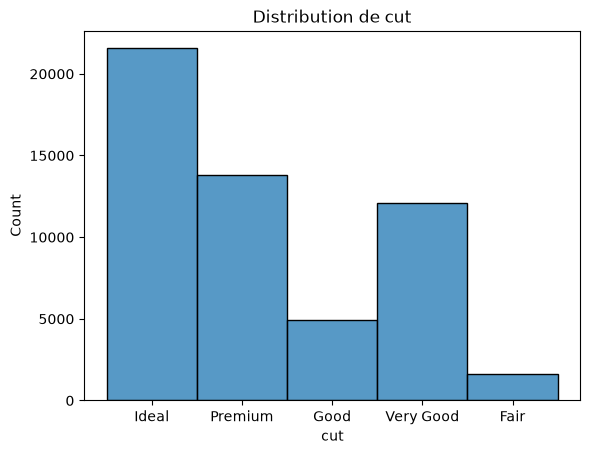

In [7]:
sns.histplot(data['cut'])
plt.title('Distribution de cut')
plt.show()

In [13]:
data['cut'].value_counts()

cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

**cut**
* Des gemmes de qualité supérieur \
La variable représentant les meilleures coupes Ideal est surreprésentée : 21551 valeurs pour cette catégorielle. A l'inverse les deux variables correspondant aux qualités les plus médiocres sont minoritaires. 4906 individus pour Good et 1610 pour Fair 

Pour ces dernières, il serait préférable de regrouper les modalités. Le désiquilibre sera encore considérable

In [14]:
data['cut'] = data['cut'].replace('Fair', 'Good')
data['cut'].value_counts()

cut
Ideal        21551
Premium      13791
Very Good    12082
Good          6516
Name: count, dtype: int64

**color**

description des variables - 
| Rang | Valeur | Signification métier                          |
| ---- | ------ | --------------------------------------------- |
|  1   | **D**  | Colorless — aucune couleur visible (meilleur) |
| 2    | **E**  | Colorless — quasi parfait                     |
| 3    | **F**  | Colorless — excellente qualité                |
| 4    | **G**  | Near Colorless — très légère teinte           |
| 5    | **H**  | Near Colorless — légère teinte                |
| 6    | **I**  | Near Colorless — teinte légèrement visible    |
| 7    | **J**  | Near Colorless — plus jaune (moins bon)       |


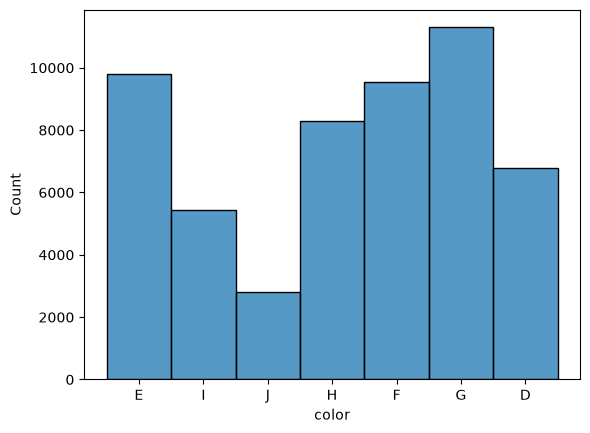

In [15]:
sns.histplot(data['color'])
plt.show()

In [16]:
data['color'].value_counts()

color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: count, dtype: int64

* Des valeurs plus ou moins équilibrées
Dans l'ensemble, les pierres sont d'excellente qualité (35% avec E et F), les categorielles étant légerement sous représenté avec I qui regroupe seulement 2808 individus ou encore I avec 5422 individus. Bien que la couleurs des pierres est dans l'ensemble de qualités, très peu de pierres sont 'parfaite' comme le montre D avec 6775 individus (12% des pierres)

* **clarity**
description des variables:

| Rang | Valeur   | Signification métier                                |
| ---- | -------- | --------------------------------------------------- |
| 1    | **IF**   | Internally Flawless — aucune inclusion interne      |
| 2    | **VVS1** | Très très petites inclusions (difficiles à voir)    |
| 3    | **VVS2** | Très très petites inclusions (un peu plus visibles) |
| 4    | **VS1**  | Très petites inclusions                             |
| 5    | **VS2**  | Très petites inclusions légèrement plus visibles    |
| 6    | **SI1**  | Petites inclusions visibles à la loupe              |
| 7    | **SI2**  | Petites inclusions plus importantes                 |
| 8    | **I1**   | Inclusions visibles                                 |
| 9    | **I2**   | Inclusions nombreuses et visibles                   |
| 10   | **I3**   | Très nombreuses inclusions (moins bonne qualité)    |


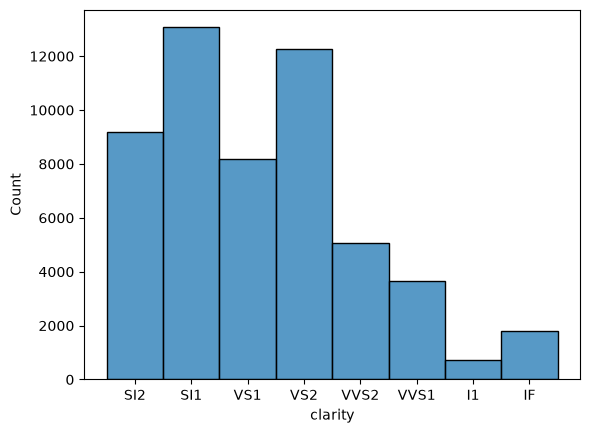

In [31]:
sns.histplot(data['clarity'])
plt.show()

In [32]:
data['clarity'].value_counts()

clarity
SI1     13065
VS2     12258
SI2      9194
VS1      8171
VVS2     5066
VVS1     3655
IF       1790
I1        741
Name: count, dtype: int64

In [39]:
print((1306500 + 1225800) // 53940)
print(179000 // 53940)
print(74100 // 53940)

46
3
1


* Des gemmes abimés sous représentés\
Les modalité représantant les pierres avec le plus d'inclusions sont sous représenté (environ 4%). Seulement deux valeurs représentent un peu moins de la moitié du dataset. SI1 et VS2. Ce sont des pierres avec des petites inclusions presques visibles